<a href="https://colab.research.google.com/github/headdown0845/2026_First-semester/blob/main/%EB%8D%B0%EC%9D%B4%ED%84%B0%EA%B4%80%EB%A6%AC%EB%A1%A0_260313(1)_%EC%9D%B4%ED%98%95%EB%AF%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import seaborn as sns
import pandas as pd

tips = sns.load_dataset('tips')

print("데이터 로드 완료. 처음 5개 행을 출력합니다.")
display(tips.head())

데이터 로드 완료. 처음 5개 행을 출력합니다.


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
df = sns.load_dataset('tips')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


# ❖seaborn의 tips 를 모집단으로 가정하고 3가지 표본추출방법을 파이썬 코드로 제시하라

In [7]:
# 1. 단순 무작위 추출
srs_sample = tips.sample(n=50, random_state=42)
#n=50 = 데이터 전체 중에서 50개의 표본(sample)을 추출
#random_state=42 = 랜덤 결과를 고정하는 값(seed)

print(f"단순 랜덤 추출 샘플 크기: {len(srs_sample)}")
print(srs_sample.head())

단순 랜덤 추출 샘플 크기: 50
     total_bill   tip     sex smoker   day    time  size
24        19.82  3.18    Male     No   Sat  Dinner     2
6          8.77  2.00    Male     No   Sun  Dinner     2
153       24.55  2.00    Male     No   Sun  Dinner     4
211       25.89  5.16    Male    Yes   Sat  Dinner     4
198       13.00  2.00  Female    Yes  Thur   Lunch     2


In [13]:
# 2. 요일(day)을 기준으로 층화 추출 (각 요일별 데이터의 20%씩 추출)
# groupby를 활용해 층을 나누고 각각 샘플링합니다.
stratified_sample = tips.groupby('day', observed=False).apply(
    lambda x: x.sample(frac=0.2, random_state=42)
)
#groupby() = 데이터를 특정 기준으로 그룹으로 나누는 함수
#observed=False = 범주형 데이터(categorical ex.성별, 도시,요일, 혈액형)일 때 모든 가능한 카테고리를 유지
#frac=0.2 = 20%추출
print("요일별 추출된 샘플 수 (층화 추출):")
print(stratified_sample['day'].value_counts())

요일별 추출된 샘플 수 (층화 추출):
day
Sat     17
Sun     15
Thur    12
Fri      4
Name: count, dtype: int64


/tmp/ipykernel_926/2142601924.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = tips.groupby('day', observed=False).apply(


In [14]:
# 2. 요일(day)을 기준으로 층화 추출 (각 요일별 데이터의 20%씩 추출)
# groupby를 활용해 층을 나누고 각각 샘플링합니다.
stratified_sample = tips.groupby('day', observed=False).apply(
    lambda x: x.sample(frac=0.2, random_state=42)
).reset_index(drop=True)
#groupby() = 데이터를 특정 기준으로 그룹으로 나누는 함수
#observed=False = 범주형 데이터(categorical ex.성별, 도시,요일, 혈액형)일 때 모든 가능한 카테고리를 유지
#frac=0.2 = 20%추출
print("요일별 추출된 샘플 수 (층화 추출):")
print(stratified_sample['day'].value_counts())

요일별 추출된 샘플 수 (층화 추출):
day
Sat     17
Sun     15
Thur    12
Fri      4
Name: count, dtype: int64


/tmp/ipykernel_926/2187474640.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = tips.groupby('day', observed=False).apply(


In [15]:
import numpy as np

# 3. 군집 추출 (요일을 군집으로 가정)
# 전체 요일 중 무작위로 2개의 요일(군집)을 선택합니다.
all_days = tips['day'].unique()
#unique() = 중복 제거
selected_clusters = np.random.choice(all_days, size=2, replace=False)
#np.random.choice() = 배열에서 랜덤으로 값을 선택하는 함수

#all_days, size=2, replace=False = 선택할 대상 (요일 목록), 2개의 요일을 선택, 중복없이 선


# 선택된 군집(요일)에 해당하는 모든 데이터를 표본으로 추출
cluster_sample = tips[tips['day'].isin(selected_clusters)]
#isin() = 특정 값 목록에 포함되는지 확인하는 함수

print(f"선택된 군집(요일): {selected_clusters}")
print(f"군집 추출 샘플 크기: {len(cluster_sample)}")
#len = 추출된 데이터의 행(row) 개수

선택된 군집(요일): ['Thur' 'Sun']
군집 추출 샘플 크기: 138


## ❖ seaborn의 tips 모집단에서 3가지 표본추출방법의 각 표본과 모집단과의 평균과 분산을 비교한 후 어떤 표본추출방법이 가장 적합한지 토론하라

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np

# 1. 데이터 로드 및 모집단 지표 계산
tips = sns.load_dataset('tips')
pop_mean = tips['total_bill'].mean()
pop_var = tips['total_bill'].var()

# 2. 표본 추출 및 지표 계산 (각각의 지표를 저장할 리스트 준비)
results = []

# --- ① 단순 랜덤 추출 (SRS) ---
srs_sample = tips.sample(n=50, random_state=42)
results.append({
    '방법': '단순 랜덤 추출',
    '표본수': len(srs_sample),
    '평균(Mean)': srs_sample['total_bill'].mean(),
    '분산(Var)': srs_sample['total_bill'].var()
})

# --- ② 층화 랜덤 추출 (Stratified) ---
# 요일(day)별로 데이터의 20%씩 추출
stratified_sample = tips.groupby('day', observed=False).apply(
    lambda x: x.sample(frac=0.2, random_state=42)
).reset_index(drop=True)
results.append({
    '방법': '층화 랜덤 추출',
    '표본수': len(stratified_sample),
    '평균(Mean)': stratified_sample['total_bill'].mean(),
    '분산(Var)': stratified_sample['total_bill'].var()
})

# --- ③ 군집 추출 (Cluster) ---
# 요일 중 2개를 무작위로 선택하여 해당 요일 데이터를 통째로 사용
all_days = tips['day'].unique()
selected_clusters = np.random.choice(all_days, size=2, replace=False)
cluster_sample = tips[tips['day'].isin(selected_clusters)]
results.append({
    '방법': f'군집 추출 ({", ".join(selected_clusters)})',
    '표본수': len(cluster_sample),
    '평균(Mean)': cluster_sample['total_bill'].mean(),
    '분산(Var)': cluster_sample['total_bill'].var()
})

# 3. 결과 비교 테이블 생성
comparison_df = pd.DataFrame(results)

# 모집단 행 추가
pop_row = pd.DataFrame([{
    '방법': '모집단 (전체)',
    '표본수': len(tips),
    '평균(Mean)': pop_mean,
    '분산(Var)': pop_var
}])
comparison_df = pd.concat([pop_row, comparison_df], ignore_index=True)

# 4. 오차(Error) 컬럼 추가 (모집단 평균과의 차이)
comparison_df['평균 오차'] = abs(comparison_df['평균(Mean)'] - pop_mean)

print("=== 표본추출 방법별 지표 비교 결과 ===")
print(comparison_df.round(3))

=== 표본추출 방법별 지표 비교 결과 ===
                 방법  표본수  평균(Mean)  분산(Var)  평균 오차
0          모집단 (전체)  244    19.786   79.253  0.000
1          단순 랜덤 추출   50    17.972   85.247  1.814
2          층화 랜덤 추출   48    20.711  101.420  0.925
3  군집 추출 (Fri, Sat)  106    19.852   87.039  0.066


/tmp/ipykernel_173/3564122107.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = tips.groupby('day', observed=False).apply(


# ❖seaborn의 tip 변수의 값(데이터) 분포, 평균과 분산을 설명하라
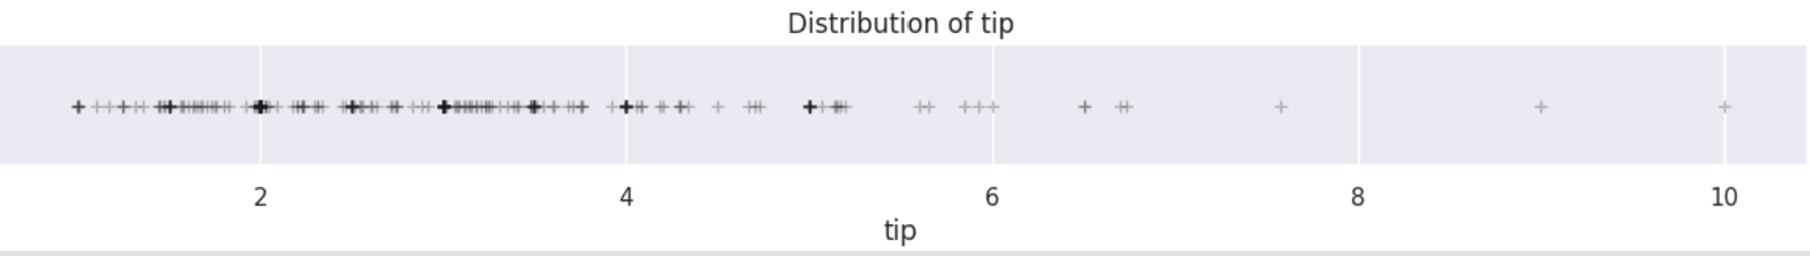

팁의 데이터 분포를 나타내는 그래프
1. 데이터 분포 (Distribution)
그래프의 형태를 보면 데이터가 왼쪽으로 쏠려 있고 오른쪽으로 긴 꼬리를 가지고 있습니다.

최빈값은 2달러에서 4달러 사이이다.

이상치(Outliers): 박스 플롯 상단에 점으로 표시된 부분입니다. 6달러 이상의 높은 팁을 주는 경우가 드물게 존재하며, 최대 10달러까지 주는 손님도 있음을 보여줍니다. 이러한 소수의 고액 팁이 전체적인 분포를 오른쪽으로 끌어당깁니다.






2. 평균 (Mean)
평균은 데이터의 모든 값을 더해 개수로 나눈 값
이 데이터의 평균은 약 3.00달러
특징: 오른쪽 꼬리가 긴 분포의 특성상, 평균은 중앙값(Median, 약 2.90달러)보다 큽니다. 소수의 고액 팁(이상치)들이 평균값을 위로 끌어올렸기 때문이다. 보통은은 3달러보다 약간 적게 주지만, 가끔 많이 주는 사람들 때문에 산술 평균은 3달러가 됩니다.


3. 분산 (Variance)
분산은 데이터가 평균으로부터 얼마나 멀리 퍼져 있는지를 나타내는 척도입니다.

퍼짐 정도: 팁 금액은 최소 1달러에서 최대 10달러까지 분포하며, 특히 2~4달러 사이에 밀집되어 있습니다.

분산의 크기: 박스 플롯의 상자 길이(IQR)가 좁은 편이지만, 상단 위스커(Whisker)가 길고 다수의 이상치가 존재하기 때문에 **어느 정도의 분산(약 1.91)**이 존재합니다. 만약 모든 손님이 딱 3달러씩만 줬다면 분산은 0이었겠지만, 이 그래프는 손님마다 팁을 주는 금액의 차이(변동성)가 꽤 있다는 것을 보여줍니다.
분산을 통해 알 수 있는 것은 보통 2~4달러 사이의 팁이지만 가끔 고액의 팁도 있다는 것을 알 수 있다.

In [ ]:
np.median(tips['tip']) #중앙값

np.float64(2.9)

In [ ]:
type(df)

pandas.core.frame.DataFrame

In [ ]:
df['tip'].mean()

np.float64(2.99827868852459)

In [ ]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [ ]:
df['time'].value_counts()

,count
time,
Dinner,176
Lunch,68
